# Spiral Drawing 기반 파킨슨병 분류 — MobileNetV2
### 수정사항
- **테스트 누수 제거**: K-Fold는 training 폴더만 사용, testing 폴더는 최종 holdout 평가용
- **Grayscale 전처리 추가**: 스캔 이미지→캔버스 도메인 갭 완화

## 1. 라이브러리 및 설정

In [11]:
import os, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import (roc_auc_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

BASE_DIR   = './parkinsons_drawings'
IMG_SIZE   = (224, 224)
BATCH_SIZE = 8
SEED       = 42
N_FOLDS    = 5
COLOR_BG   = '#F8F9FA'

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

os.makedirs('./models',  exist_ok=True)
os.makedirs('./figures', exist_ok=True)

print('TensorFlow:', tf.__version__)
print(f'BATCH_SIZE={BATCH_SIZE} | N_FOLDS={N_FOLDS}')

TensorFlow: 2.21.0
BATCH_SIZE=8 | N_FOLDS=5


## 2. 데이터 로드
> `sp_train_paths` → K-Fold 학습/검증용  
> `sp_test_paths` → 최종 holdout 평가용 (학습에 절대 포함 안 됨)

In [12]:
def collect_paths_labels(root_dir):
    classes   = sorted(os.listdir(root_dir))  # ['healthy', 'parkinson']
    label_map = {c: i for i, c in enumerate(classes)}
    print(f'  class_map: {label_map}')
    paths, labels = [], []
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(label_map[cls])
    return np.array(paths), np.array(labels)

# K-Fold 학습용 (training 폴더만)
sp_train_paths, sp_train_labels = collect_paths_labels(f'{BASE_DIR}/spiral/training')
# Holdout 평가용 (testing 폴더 — 학습에 사용 안 함)
sp_test_paths,  sp_test_labels  = collect_paths_labels(f'{BASE_DIR}/spiral/testing')

print(f'\nK-Fold 학습용: {len(sp_train_paths)}장')
print(f'  healthy:   {(sp_train_labels==0).sum()}장')
print(f'  parkinson: {(sp_train_labels==1).sum()}장')
print(f'\nHoldout 평가용: {len(sp_test_paths)}장')
print(f'  healthy:   {(sp_test_labels==0).sum()}장')
print(f'  parkinson: {(sp_test_labels==1).sum()}장')

  class_map: {'healthy': 0, 'parkinson': 1}
  class_map: {'healthy': 0, 'parkinson': 1}

K-Fold 학습용: 72장
  healthy:   36장
  parkinson: 36장

Holdout 평가용: 30장
  healthy:   15장
  parkinson: 15장


## 3. Grayscale 전처리 함수
> 스캔 이미지(RGB) → 흑백 변환 후 3채널 복제  
> 캔버스 드로잉(흑백)과 도메인 통일 → 실서비스 예측 정확도 향상

In [13]:
def to_grayscale_3ch(img):
    """RGB 이미지를 grayscale로 변환 후 3채널 복제.
    rescale=1./255 이후 호출되므로 img 범위는 [0,1]
    """
    # 가중 평균으로 grayscale 변환 (인간 시각 기준)
    gray = (0.299 * img[..., 0]
          + 0.587 * img[..., 1]
          + 0.114 * img[..., 2])
    gray = gray[..., np.newaxis]           # (H, W, 1)
    return np.concatenate([gray, gray, gray], axis=-1)  # (H, W, 3)

print('Grayscale 전처리 함수 정의 완료')

# 동작 확인
dummy = np.random.rand(224, 224, 3).astype(np.float32)
out   = to_grayscale_3ch(dummy)
print(f'입력 shape: {dummy.shape}  →  출력 shape: {out.shape}')
print(f'3채널 동일 여부: {np.allclose(out[...,0], out[...,1])}')

Grayscale 전처리 함수 정의 완료
입력 shape: (224, 224, 3)  →  출력 shape: (224, 224, 3)
3채널 동일 여부: True


## 4. Augmentation 설정

In [14]:
train_aug = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=to_grayscale_3ch,  # grayscale 변환
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    shear_range=0.08,
    brightness_range=[0.85, 1.15],
    # horizontal_flip 제거 (나선 방향 보존)
)

test_aug = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=to_grayscale_3ch,  # 평가/추론도 동일 적용
)

print('Augmentation 설정 완료 (grayscale 포함)')

Augmentation 설정 완료 (grayscale 포함)


## 5. 샘플 이미지 확인 (Grayscale 변환 후)

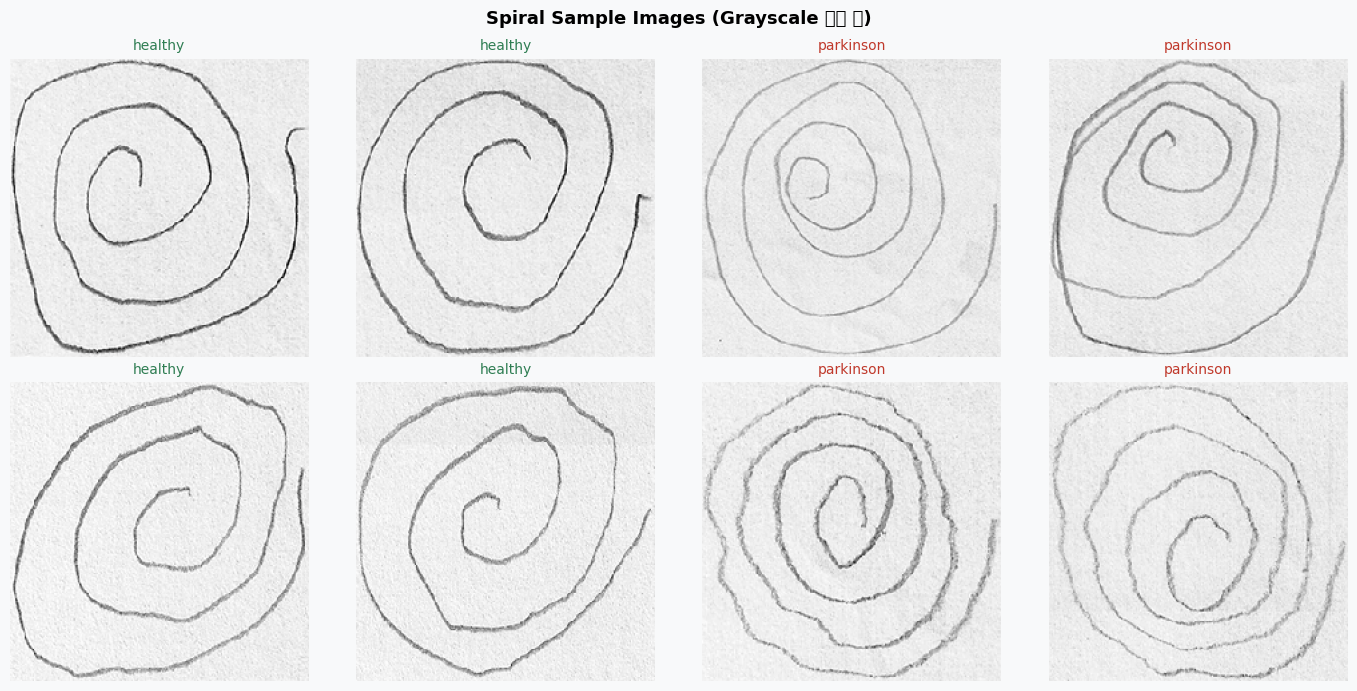

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7), facecolor=COLOR_BG)
fig.suptitle('Spiral Sample Images (Grayscale 변환 후)', fontsize=13, fontweight='bold')

for cls_idx, (cls, lbl) in enumerate([('healthy', 0), ('parkinson', 1)]):
    cls_paths = sp_train_paths[sp_train_labels == lbl][:4]
    for row, p in enumerate(cls_paths):
        ax_col = cls_idx * 2 + (row % 2)
        img = img_to_array(load_img(p, target_size=IMG_SIZE)) / 255.0
        img_gray = to_grayscale_3ch(img)
        axes[row // 2][ax_col].imshow(img_gray)
        axes[row // 2][ax_col].set_title(
            cls, fontsize=10,
            color='#2E7D52' if lbl == 0 else '#C0392B')
        axes[row // 2][ax_col].axis('off')

plt.tight_layout()
plt.savefig('./figures/samples_gray.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. MobileNetV2 모델 빌드

In [16]:
def build_model(input_shape=(224, 224, 3)):
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=input_shape)
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-3))(x)
    x = Dropout(0.3)(x)
    x = Dense(64,  activation='relu', kernel_regularizer=l2(1e-3))(x)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=output)
    return model, base

def make_generators(tr_paths, tr_labels, vl_paths, vl_labels):
    train_df = pd.DataFrame({'filename': tr_paths, 'class': tr_labels.astype(str)})
    val_df   = pd.DataFrame({'filename': vl_paths, 'class': vl_labels.astype(str)})

    train_gen = train_aug.flow_from_dataframe(
        train_df, x_col='filename', y_col='class',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', shuffle=True, seed=SEED)

    val_gen = test_aug.flow_from_dataframe(
        val_df, x_col='filename', y_col='class',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', shuffle=False)

    return train_gen, val_gen

print('모델 빌드 함수 정의 완료')

모델 빌드 함수 정의 완료


## 7. 5-Fold CV (training 데이터만 사용)
> testing 폴더 데이터는 여기서 절대 사용 안 함

In [17]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
best_auc     = 0.0
best_model   = None

# K-Fold: sp_train_paths 만 사용
for fold, (train_idx, val_idx) in enumerate(skf.split(sp_train_paths, sp_train_labels), 1):
    print(f"\n{'='*55}")
    print(f'  Fold {fold}/{N_FOLDS}  |  Train {len(train_idx)}장  Val {len(val_idx)}장')
    print(f"{'='*55}")

    tr_paths, tr_labels = sp_train_paths[train_idx], sp_train_labels[train_idx]
    vl_paths, vl_labels = sp_train_paths[val_idx],   sp_train_labels[val_idx]

    # 클래스 불균형 대응
    cw = compute_class_weight('balanced', classes=np.unique(tr_labels), y=tr_labels)
    class_weight_dict = dict(enumerate(cw))

    train_gen, val_gen = make_generators(tr_paths, tr_labels, vl_paths, vl_labels)
    model, base = build_model()

    # Stage 1 — classifier only
    print('\n[Stage 1] Classifier 학습 (base freeze)')
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    cb1 = [
        EarlyStopping(monitor='val_auc', patience=10,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6)
    ]
    model.fit(train_gen, validation_data=val_gen,
              epochs=40, callbacks=cb1,
              class_weight=class_weight_dict, verbose=1)

    # Stage 2 — fine-tuning
    print('\n[Stage 2] Fine-tuning (상위 30레이어 unfreeze, lr=1e-5)')
    for layer in base.layers[-30:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

    model.compile(optimizer=Adam(1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    cb2 = [
        EarlyStopping(monitor='val_auc', patience=8,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-7)
    ]
    model.fit(train_gen, validation_data=val_gen,
              epochs=30, callbacks=cb2,
              class_weight=class_weight_dict, verbose=1)

    # Fold 평가
    eval_df  = pd.DataFrame({'filename': vl_paths, 'class': vl_labels.astype(str)})
    eval_gen = test_aug.flow_from_dataframe(
        eval_df, x_col='filename', y_col='class',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', shuffle=False)

    preds  = model.predict(eval_gen, verbose=0).flatten()
    labels = eval_gen.labels

    auc  = roc_auc_score(labels, preds)
    sens = recall_score(labels, (preds > 0.5).astype(int))
    spec = recall_score(labels, (preds > 0.5).astype(int), pos_label=0)
    f1   = f1_score(labels, (preds > 0.5).astype(int))

    fold_results.append({'Fold': fold, 'AUC': auc,
                         'Sensitivity': sens, 'Specificity': spec, 'F1': f1})
    print(f'\n  Fold {fold} | AUC={auc:.4f} | Sens={sens:.4f} | Spec={spec:.4f} | F1={f1:.4f}')

    if auc > best_auc:
        best_auc   = auc
        best_model = model
        print('  >> Best AUC 갱신')

print(f"\n{'='*55}")
print(f'K-Fold 완료  |  Best CV AUC: {best_auc:.4f}')
print(f"{'='*55}")


  Fold 1/5  |  Train 57장  Val 15장
Found 57 validated image filenames belonging to 2 classes.
Found 15 validated image filenames belonging to 2 classes.

[Stage 1] Classifier 학습 (base freeze)
Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 586ms/step - accuracy: 0.5439 - auc: 0.5683 - loss: 1.0521 - val_accuracy: 0.5333 - val_auc: 0.8482 - val_loss: 0.9087 - learning_rate: 0.0010
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.5263 - auc: 0.5610 - loss: 1.0916 - val_accuracy: 0.6667 - val_auc: 0.8036 - val_loss: 0.8370 - learning_rate: 0.0010
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5789 - auc: 0.6416 - loss: 1.0220 - val_accuracy: 0.6667 - val_auc: 0.7857 - val_loss: 0.8857 - learning_rate: 0.0010
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.7018 - auc: 0.7629 - loss: 0.8640 - val_accuracy: 0.6000 - val_auc: 0.8036 - val_loss: 0.8078 - learning_rate: 0.0010
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.6491 - auc: 0.6

## 8. K-Fold 결과 요약

[Fold별 성능]
 Fold      AUC  Sensitivity  Specificity       F1
    1 0.839286     0.142857     1.000000 0.250000
    2 1.000000     0.750000     1.000000 0.857143
    3 1.000000     0.428571     1.000000 0.600000
    4 0.959184     0.714286     0.857143 0.769231
    5 0.918367     0.714286     1.000000 0.833333

[평균 +/- 표준편차]
  AUC            : 0.9434 +/- 0.0673
  Sensitivity    : 0.5500 +/- 0.2620
  Specificity    : 0.9714 +/- 0.0639
  F1             : 0.6619 +/- 0.2513


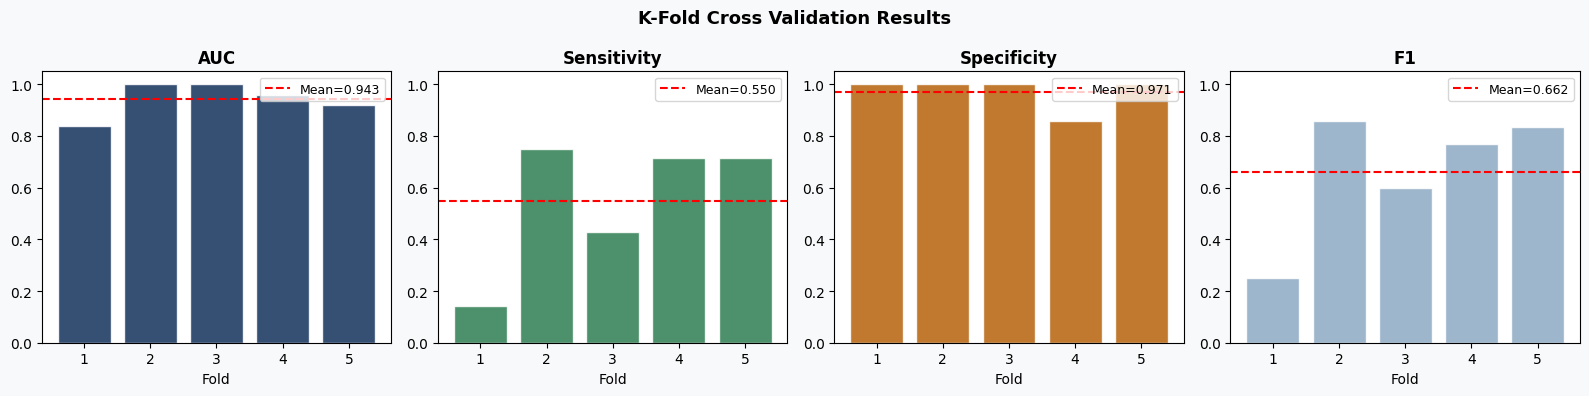

In [18]:
df = pd.DataFrame(fold_results)
print('[Fold별 성능]')
print(df.to_string(index=False))
print('\n[평균 +/- 표준편차]')
for col in ['AUC', 'Sensitivity', 'Specificity', 'F1']:
    print(f'  {col:<15}: {df[col].mean():.4f} +/- {df[col].std():.4f}')

fig, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor=COLOR_BG)
fig.suptitle('K-Fold Cross Validation Results', fontsize=13, fontweight='bold')
colors = ['#13315C', '#2E7D52', '#B5620A', '#8DA9C4']
for ax, metric, color in zip(axes, ['AUC','Sensitivity','Specificity','F1'], colors):
    vals = df[metric].values
    ax.bar(range(1, N_FOLDS+1), vals, color=color, alpha=0.85, edgecolor='white')
    ax.axhline(vals.mean(), color='red', linestyle='--', lw=1.5,
               label=f'Mean={vals.mean():.3f}')
    ax.set_xlabel('Fold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('./figures/kfold_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 모델 저장 + Holdout 최종 평가
> 여기서 처음으로 `sp_test_paths` 사용 (학습에 한 번도 포함 안 된 데이터)

In [19]:
best_model.save('./models/spiral_model.keras')
print('spiral_model.keras 저장 완료')

# Holdout 평가 (testing 폴더 — 완전한 미지 데이터)
test_df  = pd.DataFrame({'filename': sp_test_paths,
                          'class':    sp_test_labels.astype(str)})
test_gen = test_aug.flow_from_dataframe(
    test_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

loaded = tf.keras.models.load_model('./models/spiral_model.keras')
preds  = loaded.predict(test_gen, verbose=0).flatten()
labels = test_gen.labels

print(f'class_indices: {test_gen.class_indices}')
print(f'healthy   예측 평균: {preds[labels==0].mean():.4f}  (낮을수록 정상)')
print(f'parkinson 예측 평균: {preds[labels==1].mean():.4f}  (높을수록 PD)')
print(f'\n=== Holdout 최종 성능 ===')
print(f'AUC:         {roc_auc_score(labels, preds):.4f}')
print(f'Sensitivity: {recall_score(labels, (preds>0.5).astype(int)):.4f}')
print(f'Specificity: {recall_score(labels, (preds>0.5).astype(int), pos_label=0):.4f}')
print(f'F1:          {f1_score(labels, (preds>0.5).astype(int)):.4f}')
print(classification_report(labels, (preds>0.5).astype(int),
                             target_names=['healthy','parkinson']))

spiral_model.keras 저장 완료
Found 30 validated image filenames belonging to 2 classes.
class_indices: {'0': 0, '1': 1}
healthy   예측 평균: nan  (낮을수록 정상)
parkinson 예측 평균: nan  (높을수록 PD)

=== Holdout 최종 성능 ===
AUC:         0.8311
Sensitivity: 0.6667
Specificity: 0.8667
F1:          0.7407
              precision    recall  f1-score   support

     healthy       0.72      0.87      0.79        15
   parkinson       0.83      0.67      0.74        15

    accuracy                           0.77        30
   macro avg       0.78      0.77      0.76        30
weighted avg       0.78      0.77      0.76        30



## 10. Confusion Matrix (Holdout)

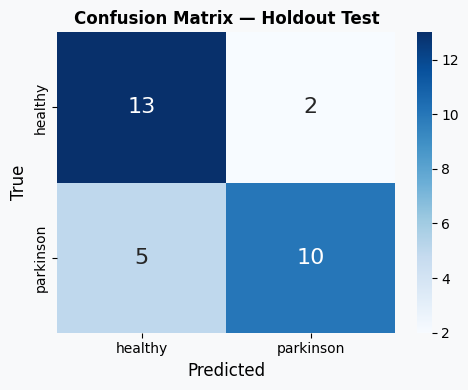

In [20]:
cm = confusion_matrix(labels, (preds > 0.5).astype(int))
fig, ax = plt.subplots(1, 1, figsize=(5, 4), facecolor=COLOR_BG)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['healthy', 'parkinson'],
            yticklabels=['healthy', 'parkinson'],
            annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('Confusion Matrix — Holdout Test', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./figures/confusion_matrix_holdout.png', dpi=150, bbox_inches='tight')
plt.show()